# Lending Club Credit Risk — Exploratory Data Analysis
**Dataset**: Lending Club Accepted Loans 2007–2018 Q4  
**Goal**: Understand the data structure, define the default target, and surface key risk drivers through visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [2]:
df_raw = pd.read_csv('accepted_2007_to_2018Q4.csv.gz', low_memory=False)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Define Target Variable
We keep only **closed** loans and label them:
- **1 (Default)** → `Charged Off` and `Does not meet the credit policy. Status:Charged Off`
- **0 (Good)** → `Fully Paid` and `Does not meet the credit policy. Status:Fully Paid`

The "Does not meet credit policy" variants are historical loans that no longer pass current underwriting standards but have valid closed outcomes — excluding them would disproportionately drop early-year (2007–2009) records.

In [3]:
default_statuses = {'Charged Off', 'Does not meet the credit policy. Status:Charged Off'}
good_statuses    = {'Fully Paid',   'Does not meet the credit policy. Status:Fully Paid'}
closed_statuses  = default_statuses | good_statuses

df = df_raw[df_raw['loan_status'].isin(closed_statuses)].copy()
df['default'] = df['loan_status'].isin(default_statuses).astype(int)

print(f'Usable loans: {len(df):,}')
print(df['default'].value_counts().rename({0: 'Good (Fully Paid)', 1: 'Default (Charged Off)'}))

Usable loans: 1,348,059
default
Good (Fully Paid)        1078739
Default (Charged Off)     269320
Name: count, dtype: int64


## 3. Target Class Imbalance

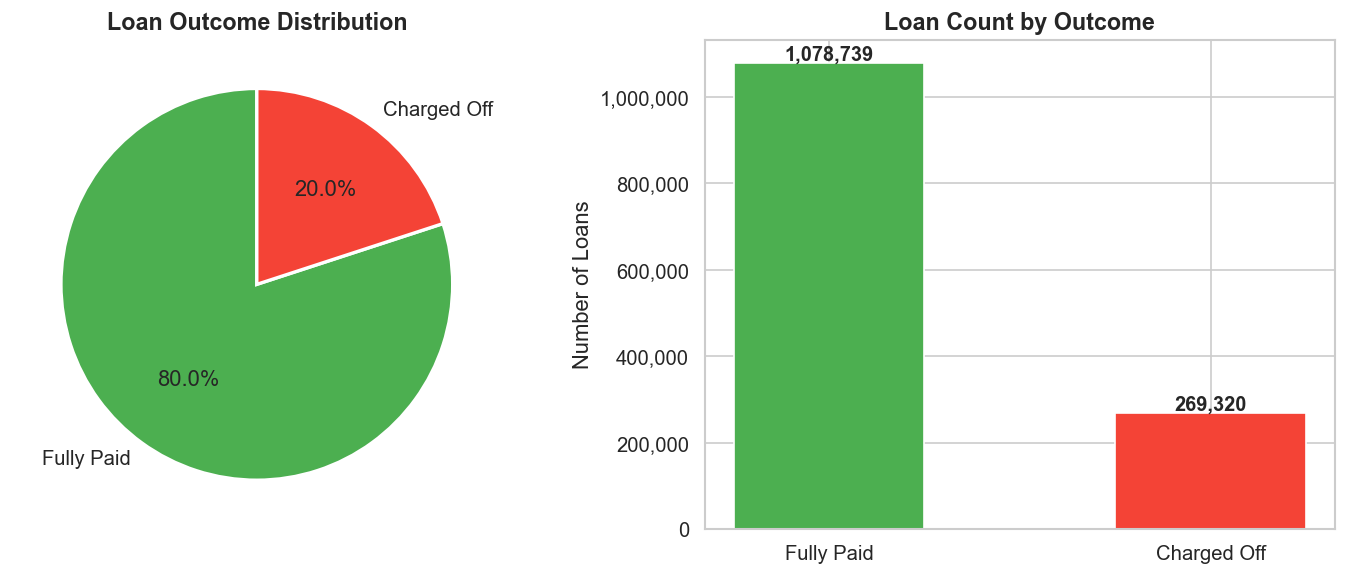

In [4]:
counts = df['default'].value_counts()
labels = ['Fully Paid', 'Charged Off']
colors = ['#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Loan Outcome Distribution', fontsize=14, fontweight='bold')

bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Loan Count by Outcome', fontsize=14, fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].set_ylabel('Number of Loans')

plt.tight_layout()
plt.savefig('fig_01_class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Default Rate Over Time

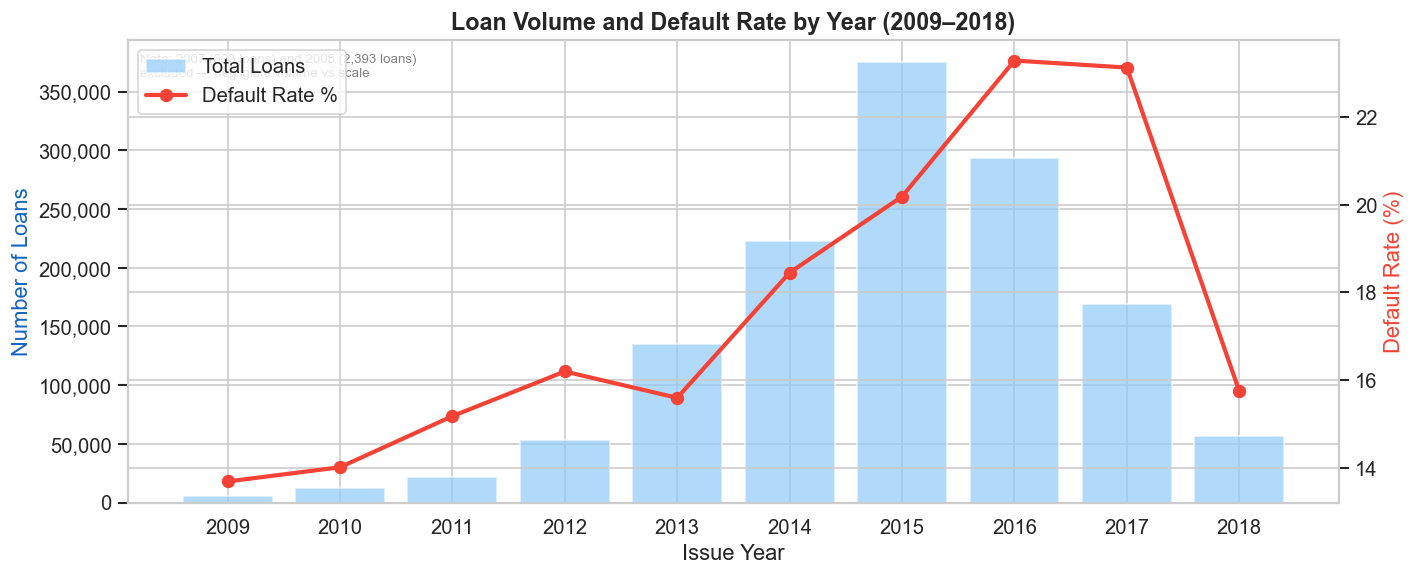

In [5]:
df['issue_year'] = pd.to_datetime(df['issue_d'], format='%b-%Y').dt.year

# 2007 (603 loans) and 2008 (2,393 loans) are negligible vs 400K+ in peak years
# and would be invisible on this scale — start from 2009 for a readable chart
yearly = df[df['issue_year'] >= 2009].groupby('issue_year').agg(
    total=('default', 'count'),
    defaults=('default', 'sum')
).reset_index()
yearly['default_rate'] = yearly['defaults'] / yearly['total'] * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(yearly['issue_year'], yearly['total'], color='#90CAF9', alpha=0.7, label='Total Loans')
ax2.plot(yearly['issue_year'], yearly['default_rate'], color='#F44336',
         marker='o', linewidth=2.5, markersize=7, label='Default Rate %')

ax1.set_xlabel('Issue Year')
ax1.set_ylabel('Number of Loans', color='#1565C0')
ax2.set_ylabel('Default Rate (%)', color='#F44336')
ax1.set_title('Loan Volume and Default Rate by Year (2009–2018)', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_xticks(yearly['issue_year'])

# Note about excluded early years
ax1.annotate('Note: 2007 (603 loans) and 2008 (2,393 loans)\nexcluded — negligible volume vs scale',
             xy=(0.01, 0.97), xycoords='axes fraction',
             fontsize=8, color='gray', va='top')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('fig_02_default_rate_over_time.png', bbox_inches='tight')
plt.show()

## 5. Loan Grade vs Default Rate

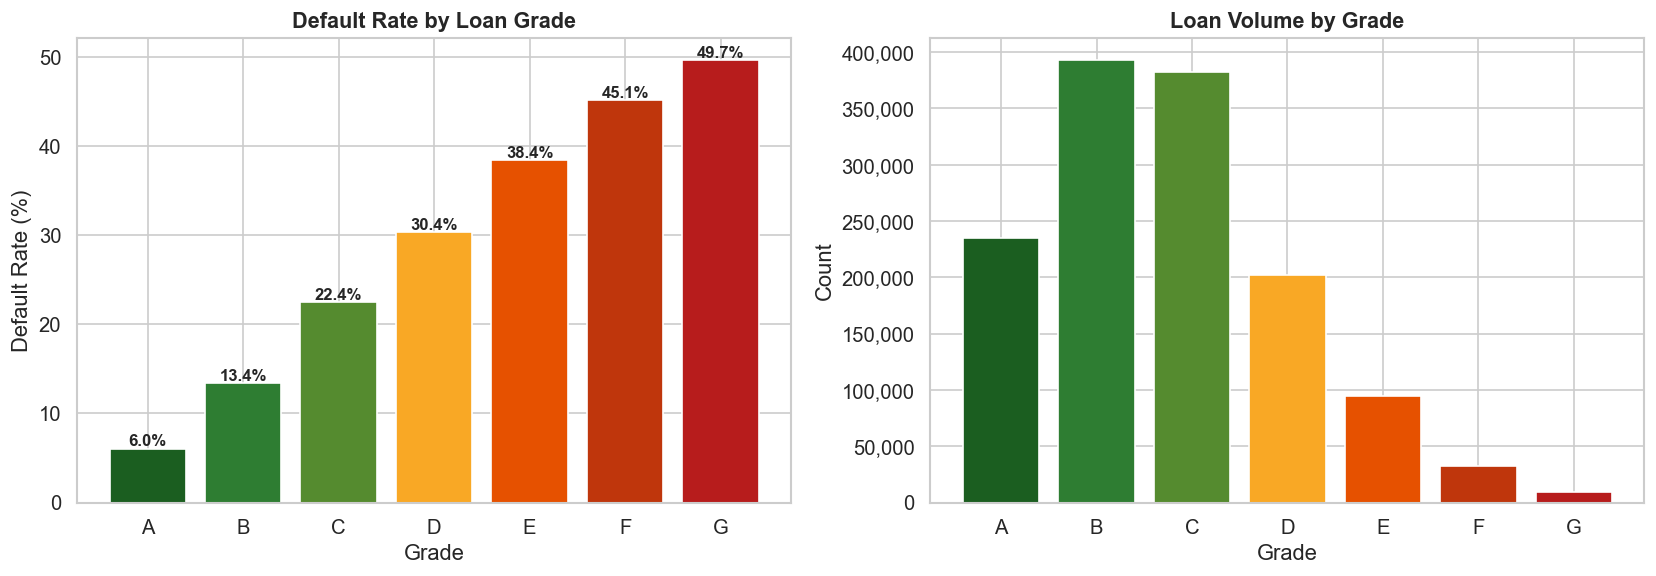

In [6]:
grade_df = df.groupby('grade').agg(
    total=('default', 'count'),
    default_rate=('default', 'mean')
).reset_index()
grade_df['default_rate'] *= 100
grade_df = grade_df.sort_values('grade')

colors_grade = ['#1B5E20','#2E7D32','#558B2F','#F9A825','#E65100','#BF360C','#B71C1C']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(grade_df['grade'], grade_df['default_rate'],
                   color=colors_grade, edgecolor='white')
for bar, val in zip(bars, grade_df['default_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Default Rate by Loan Grade', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Default Rate (%)')

axes[1].bar(grade_df['grade'], grade_df['total'], color=colors_grade, edgecolor='white')
axes[1].set_title('Loan Volume by Grade', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('fig_03_grade_analysis.png', bbox_inches='tight')
plt.show()

## 6. Interest Rate Distribution by Outcome

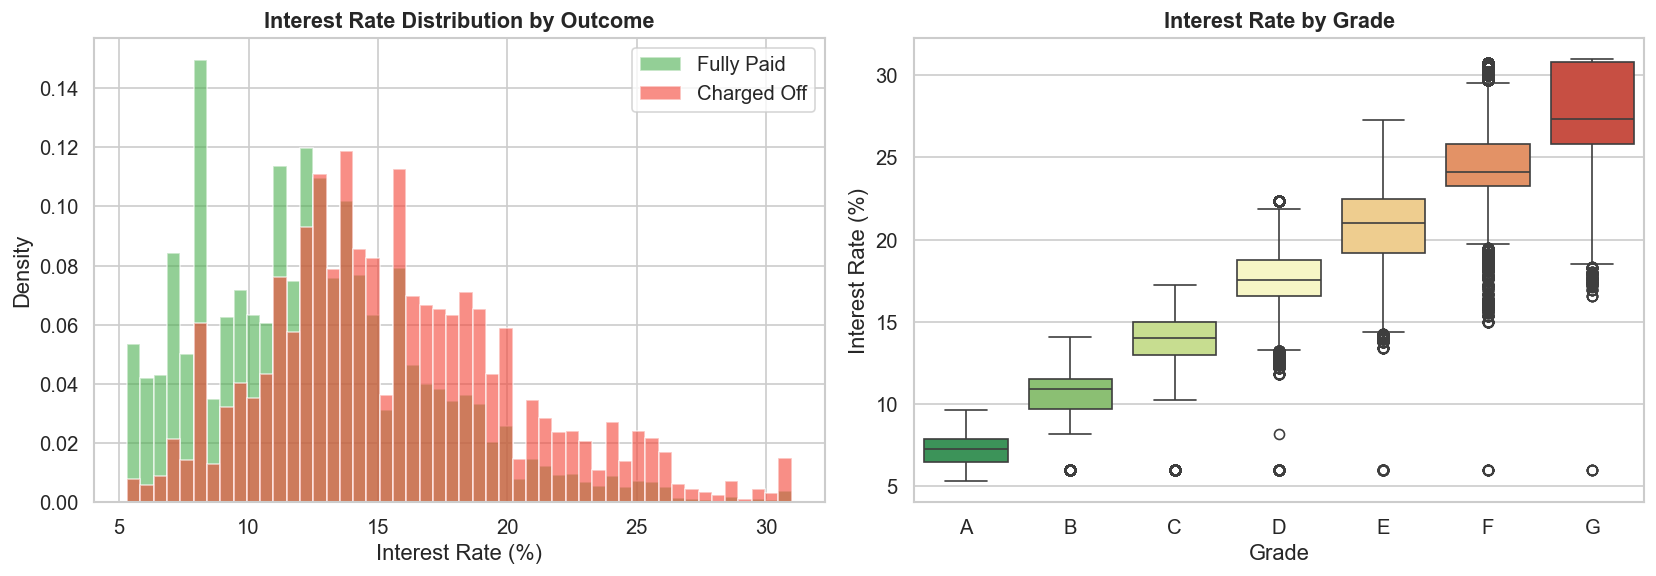

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for outcome, color, label in [(0, '#4CAF50', 'Fully Paid'), (1, '#F44336', 'Charged Off')]:
    subset = df[df['default'] == outcome]['int_rate']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
axes[0].set_title('Interest Rate Distribution by Outcome', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Interest Rate (%)')
axes[0].set_ylabel('Density')
axes[0].legend()

sns.boxplot(data=df, x='grade', y='int_rate', order=list('ABCDEFG'),
            palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('Interest Rate by Grade', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Interest Rate (%)')

plt.tight_layout()
plt.savefig('fig_04_interest_rate.png', bbox_inches='tight')
plt.show()

## 7. Loan Purpose vs Default Rate

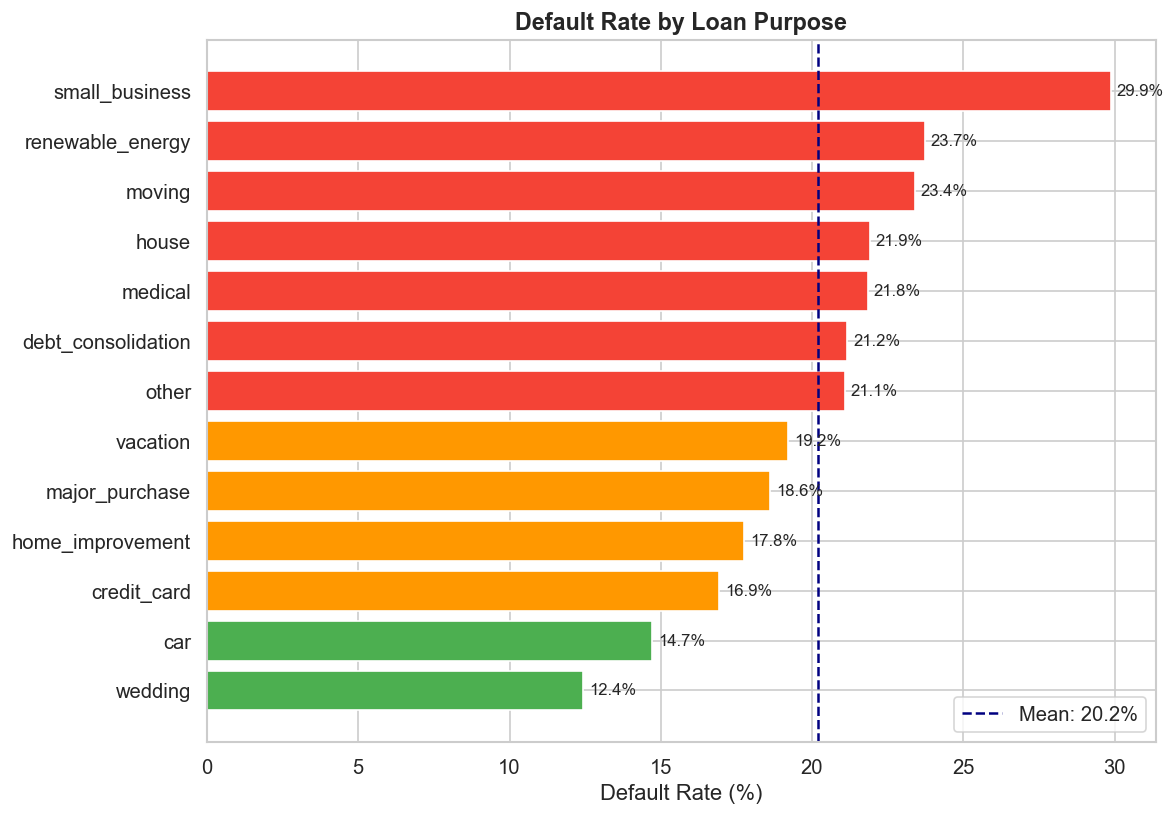

In [8]:
purpose_df = df.groupby('purpose').agg(
    total=('default', 'count'),
    default_rate=('default', 'mean')
).reset_index()
purpose_df['default_rate'] *= 100
purpose_df = purpose_df[purpose_df['total'] > 500].sort_values('default_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_p = ['#F44336' if r > 20 else '#FF9800' if r > 15 else '#4CAF50'
            for r in purpose_df['default_rate']]
bars = ax.barh(purpose_df['purpose'], purpose_df['default_rate'], color=colors_p)
for bar, val in zip(bars, purpose_df['default_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_title('Default Rate by Loan Purpose', fontsize=14, fontweight='bold')
ax.set_xlabel('Default Rate (%)')
ax.axvline(purpose_df['default_rate'].mean(), color='navy', linestyle='--',
           linewidth=1.5, label=f"Mean: {purpose_df['default_rate'].mean():.1f}%")
ax.legend()
plt.tight_layout()
plt.savefig('fig_05_purpose_default.png', bbox_inches='tight')
plt.show()

## 8. Key Numeric Features: KDE by Outcome

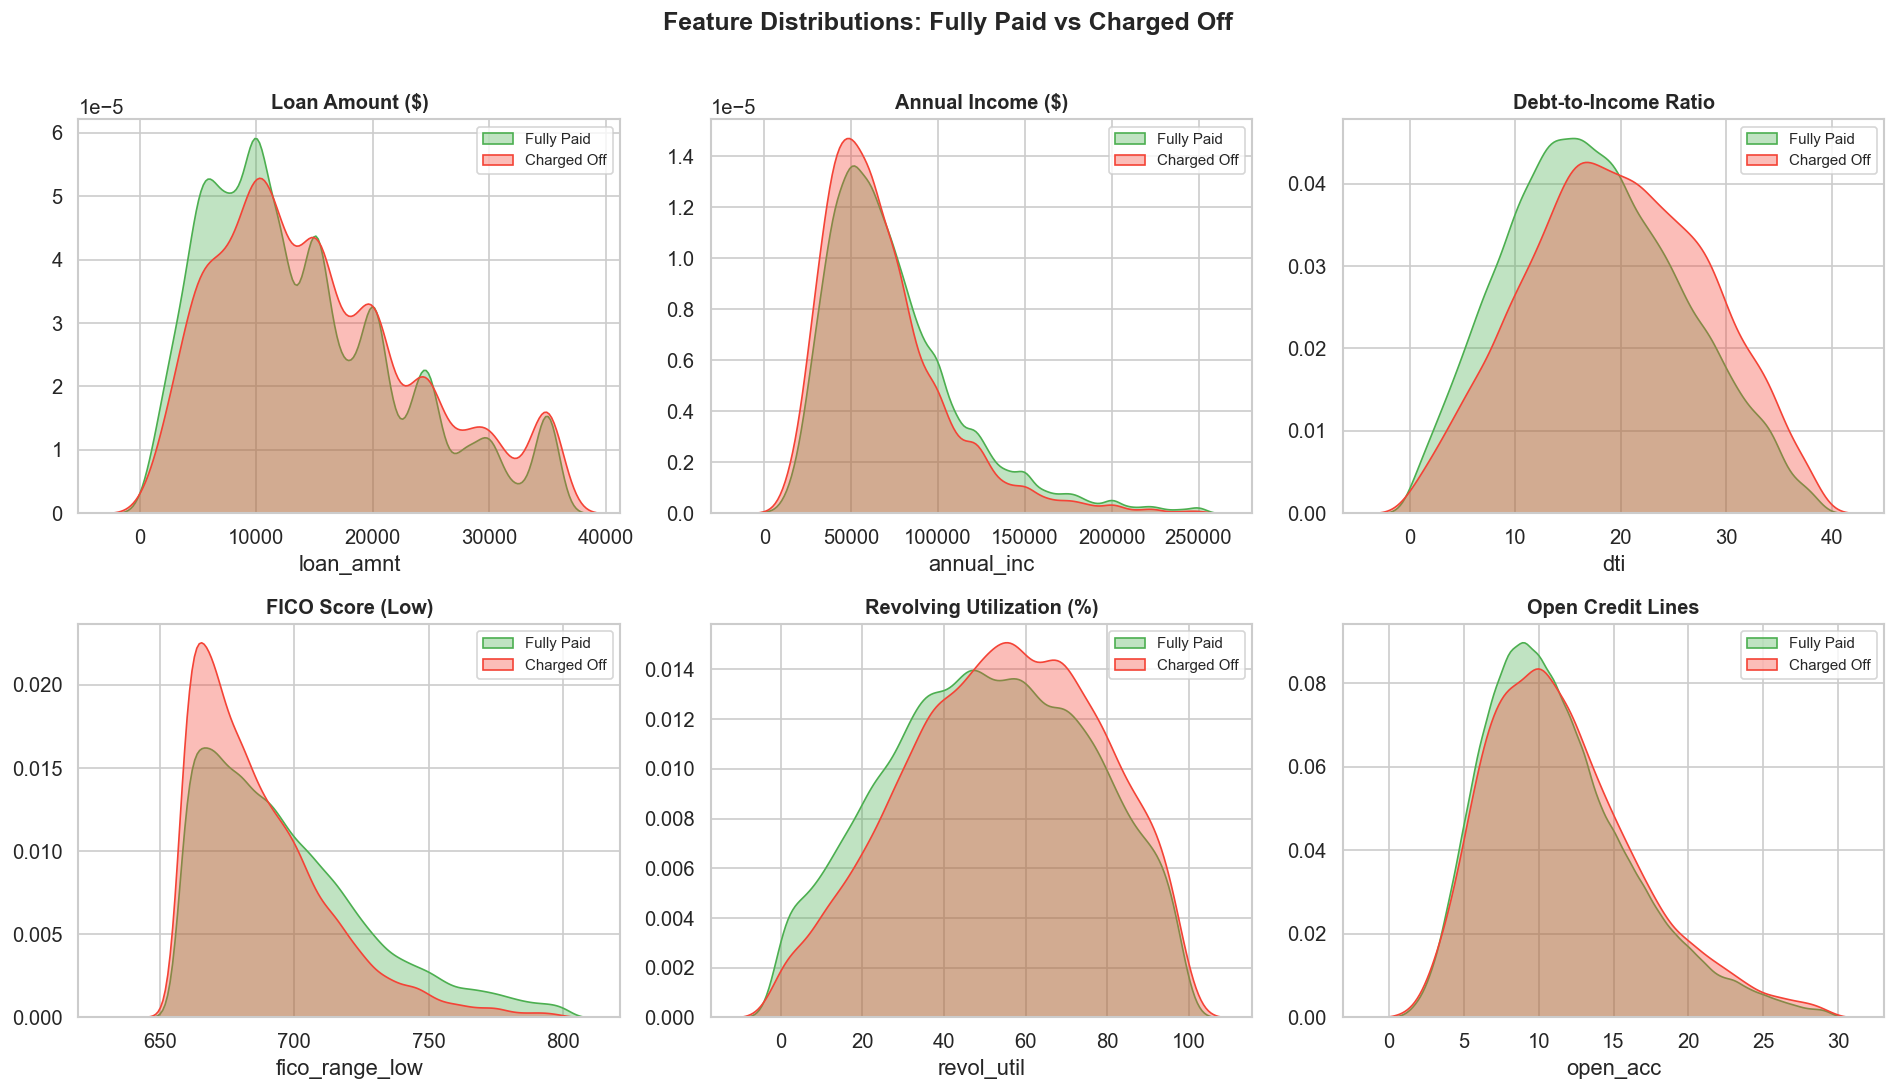

In [9]:
features = ['loan_amnt', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'open_acc']
labels_map = {
    'loan_amnt': 'Loan Amount ($)',
    'annual_inc': 'Annual Income ($)',
    'dti': 'Debt-to-Income Ratio',
    'fico_range_low': 'FICO Score (Low)',
    'revol_util': 'Revolving Utilization (%)',
    'open_acc': 'Open Credit Lines'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sample = df[df[feat].notna()].sample(min(50000, len(df)), random_state=42)
    cap = sample[feat].quantile(0.99)
    sample = sample[sample[feat] <= cap]
    for outcome, color, label in [(0, '#4CAF50', 'Fully Paid'), (1, '#F44336', 'Charged Off')]:
        subset = sample[sample['default'] == outcome][feat]
        sns.kdeplot(subset, ax=axes[i], color=color, fill=True, alpha=0.35, label=label)
    axes[i].set_title(labels_map[feat], fontsize=12, fontweight='bold')
    axes[i].set_ylabel('')
    axes[i].legend(fontsize=9)

fig.suptitle('Feature Distributions: Fully Paid vs Charged Off', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_06_feature_kde.png', bbox_inches='tight')
plt.show()

## 9. Correlation Heatmap (Key Features)

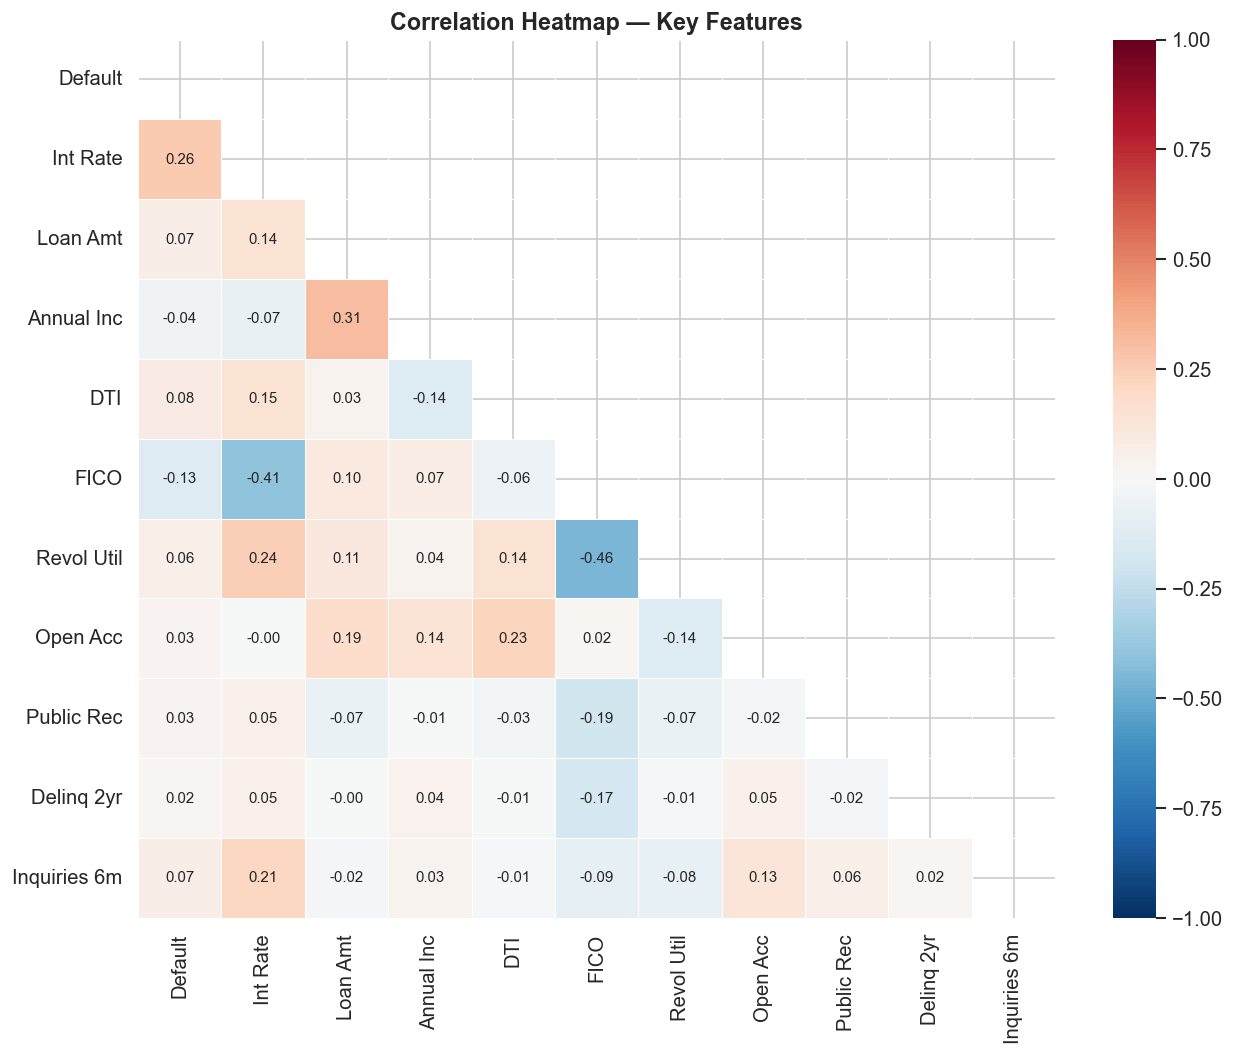

In [10]:
corr_features = ['default', 'int_rate', 'loan_amnt', 'annual_inc',
                 'dti', 'fico_range_low', 'revol_util', 'open_acc',
                 'pub_rec', 'delinq_2yrs', 'inq_last_6mths']
corr_labels = ['Default', 'Int Rate', 'Loan Amt', 'Annual Inc',
               'DTI', 'FICO', 'Revol Util', 'Open Acc',
               'Public Rec', 'Delinq 2yr', 'Inquiries 6m']

corr_matrix = df[corr_features].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Heatmap — Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 10. Missing Value Analysis

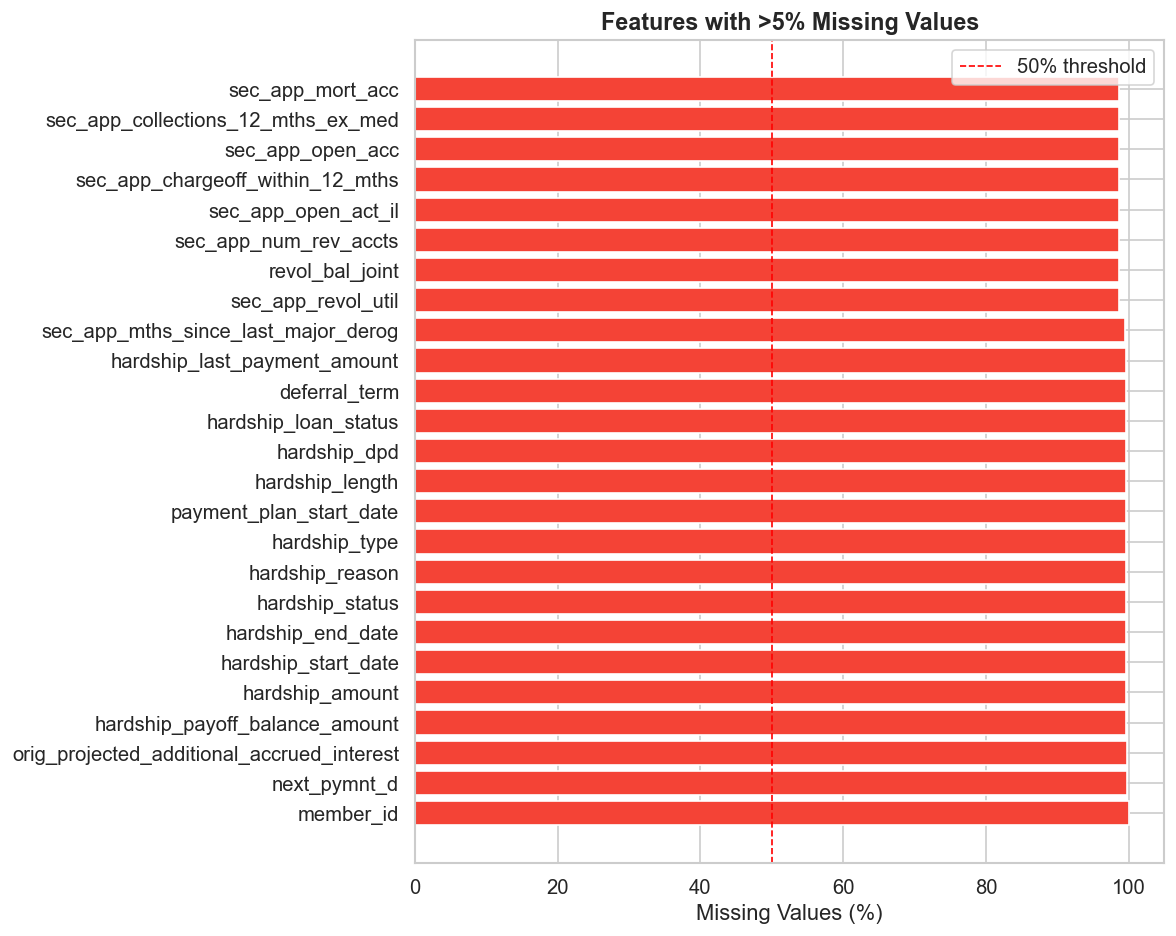

Columns with >50% missing (will drop): 25


In [11]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0.05].head(25) * 100

fig, ax = plt.subplots(figsize=(10, 8))
colors_m = ['#F44336' if v > 50 else '#FF9800' if v > 20 else '#FFC107'
            for v in missing.values]
ax.barh(missing.index, missing.values, color=colors_m)
ax.set_xlabel('Missing Values (%)')
ax.set_title('Features with >5% Missing Values', fontsize=14, fontweight='bold')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_08_missing_values.png', bbox_inches='tight')
plt.show()

print(f'Columns with >50% missing (will drop): {(missing > 50).sum()}')

## 11. Home Ownership vs Default Rate

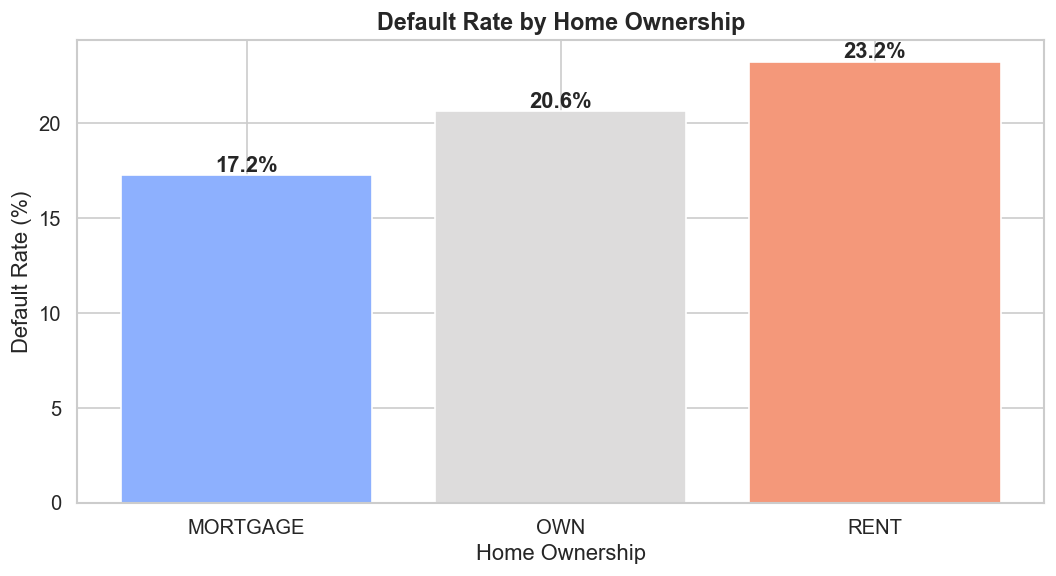

In [12]:
home_df = df.groupby('home_ownership').agg(
    total=('default', 'count'),
    default_rate=('default', 'mean')
).reset_index()
home_df['default_rate'] *= 100
home_df = home_df[home_df['total'] > 1000].sort_values('default_rate')

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette('coolwarm', len(home_df))
bars = ax.bar(home_df['home_ownership'], home_df['default_rate'], color=palette)
for bar, val in zip(bars, home_df['default_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Default Rate by Home Ownership', fontsize=14, fontweight='bold')
ax.set_xlabel('Home Ownership')
ax.set_ylabel('Default Rate (%)')
plt.tight_layout()
plt.savefig('fig_09_home_ownership.png', bbox_inches='tight')
plt.show()

## 12. EDA Summary

| Finding | Implication for Modeling |
|---|---|
| ~20% default rate — moderate imbalance | Use `scale_pos_weight` or SMOTE |
| Grade & int_rate strongly predict default | Include and engineer from these |
| FICO score inversely correlated with default | Key feature, low missing rate |
| DTI positively correlated with default | Important risk driver (economics background!) |
| Many joint/hardship cols >80% missing | Drop these columns |
| Small business loans have highest default rate | Consider purpose as a feature |